<a href="https://colab.research.google.com/github/NahomiHM/Procesos-estocasticos/blob/main/MATRIZFUNDAMENTAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Serpientes y escaleras 12/05/26
con simulaci
Resolver analíticamente y por simulación en un cuaderno de Jupyter Notebook.

¿Cuál es el número promedio de tiradas necesarias para terminar el juego de serpientes y escaleras en el tablero de la imagen adjunta?

Resolver a detalle.


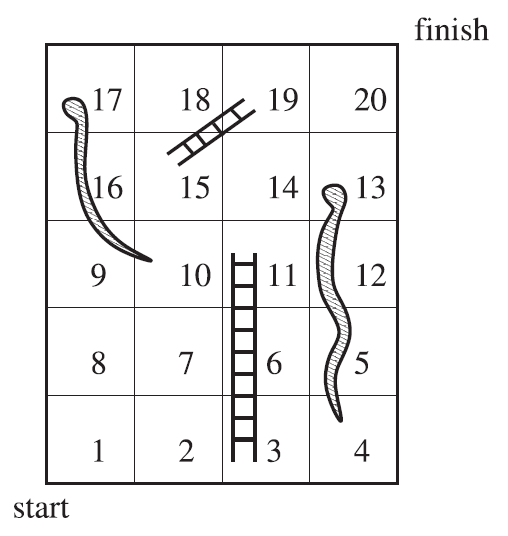



In [ ]:
import numpy as np
import sympy as sp

n_casillas = 20
Q = sp.zeros(n_casillas, n_casillas)
prob = sp.Rational(1, 6)

# Definir saltos (escaleras y serpientes)
saltos = {3: 11, 15: 19, 17: 9, 13: 5}

for i in range(n_casillas): # De 0 a 19
    for dado in range(1, 7):
        destino = i + dado
        if destino > n_casillas:
            destino = n_casillas

        destino_final = saltos.get(destino, destino)

        if destino_final < n_casillas:
            Q[i, destino_final] += prob

I = sp.eye(n_casillas)
N = (I - Q).inv()
tiempo_esperado = sum(N.row(0))

print(f"Número promedio de tiradas (Analítico): {float(tiempo_esperado):.4f}")

# --- PARTE DE SIMULACIÓN ---
def simular_juego():
    pos = 0
    tiros = 0
    while pos < 20:
        tiros += 1
        dado = np.random.randint(1, 7)
        pos += dado
        if pos > 20: pos = 20
        pos = saltos.get(pos, pos)
    return tiros

n_sim = 100000
promedio_sim = np.mean([simular_juego() for _ in range(n_sim)])
print(f"Número promedio de tiradas (Simulación): {promedio_sim:.4f}")

Número promedio de tiradas (Analítico): 7.0521
Número promedio de tiradas (Simulación): 7.0549


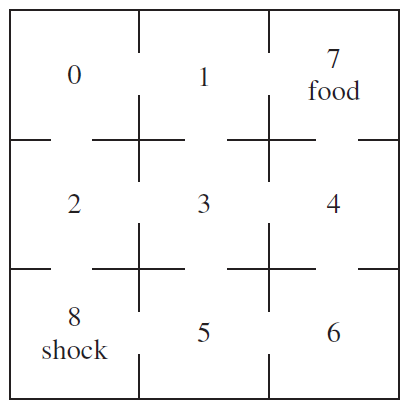

In [ ]:
# Definición de la matriz según las puertas de la imagen 1000021985.jpg
P = sp.zeros(9, 9)
# Conexiones (k = número de puertas)
P[0, 1] = P[0, 2] = sp.Rational(1, 2)
P[1, 0] = P[1, 3] = P[1, 7] = sp.Rational(1, 3) # 7 es Food
P[2, 0] = P[2, 3] = P[2, 8] = sp.Rational(1, 3) # 8 es Shock
P[3, 1] = P[3, 2] = P[3, 4] = P[3, 5] = sp.Rational(1, 4)
P[4, 3] = P[4, 6] = P[4, 7] = sp.Rational(1, 3)
P[5, 3] = P[5, 6] = P[5, 8] = sp.Rational(1, 3)
P[6, 4] = P[6, 5] = sp.Rational(1, 2)

# Matrices Q y R
Q_rata = P[0:7, 0:7]
R_rata = P[0:7, 7:9]

# Cálculo de Probabilidades de Absorción
B_rata = (sp.eye(7) - Q_rata).inv() * R_rata

# Resultado para el estado inicial 0 hacia la comida (columna 0 de B)
prob_comida = B_rata[0, 0]
print(f"Probabilidad de que la rata alcance la comida (Analítico): {prob_comida}")
print(f"Valor decimal: {float(prob_comida):.4f}")

Probabilidad de que la rata alcance la comida (Analítico): 1/2
Valor decimal: 0.5000
